In [1]:
import geopandas as gpd
import pandas as pd
import fiona

gpkg_path = r"C:\SoilGrids\data\Ubicacion_Estacion Principal.gpkg"
layers = fiona.listlayers(gpkg_path)

records = []
source_crs = None

for layer_name in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer_name)
    if gdf.empty:
        continue

    point_rows = gdf[gdf.geometry.geom_type.isin(["Point", "MultiPoint"])].copy()
    if point_rows.empty:
        continue

    source_crs = gdf.crs
    point_rows["x"] = point_rows.geometry.x
    point_rows["y"] = point_rows.geometry.y
    point_rows["layer"] = layer_name

    if source_crs is not None:
        point_rows_wgs84 = point_rows.to_crs(4326)
        point_rows["longitude"] = point_rows_wgs84.geometry.x
        point_rows["latitude"] = point_rows_wgs84.geometry.y
    else:
        point_rows["longitude"] = pd.NA
        point_rows["latitude"] = pd.NA

    records.append(point_rows[["layer", "x", "y", "longitude", "latitude", "geometry"]])

if not records:
    raise ValueError("No point geometries were found in the geopackage.")

coords_df = pd.concat(records, ignore_index=True)
print(f"Layers: {list(layers)}")
print(f"Source CRS: {source_crs}")
coords_df

DriverError: Failed to open dataset (flags=68): C:\SoilGrids\data\Ubicacion_Estacion Principal.gpkg

In [1]:
import pandas as pd
import numpy as np

# Load TDR data
tdr_path = r"TDR_data\TDR_ladera_zhurucay_2021_09_2026_03.csv"
df_tdr = pd.read_csv(tdr_path, parse_dates=["TIMESTAMP"])

# Drop duplicate timestamps if any
df_tdr = df_tdr.drop_duplicates(subset="TIMESTAMP")

# Set TIMESTAMP as index and resample to daily mean
df_tdr = df_tdr.set_index("TIMESTAMP")
df_day = df_tdr.resample("D").mean()
df_day.index.name = "Date"

# Save daily averages to a new CSV
output_path = r"TDR_data\TDR_ladera_zhurucay_daily_avg.csv"
df_day.to_csv(output_path)

print(f"Daily averages saved to: {output_path}")
print(f"Shape: {df_day.shape}")
df_day.head()


Daily averages saved to: TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 12)


,VW_Avg(14),VW_Avg(15),VW_Avg(16),VW_Avg(17),VW_Avg(18),VW_Avg(19),VW_Avg(20),VW_Avg(21),VW_Avg(22),VW_Avg(23),VW_Avg(24),VW_Avg(25)
Date,,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.363260,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.361917,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.394344,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.399878,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.375840,0.686802,0.728819,0.672569,0.826424


In [2]:
# Compute the mean across all sensors for each day
df_day_mean = df_day.mean(axis=1).rename("VW_mean_all_sensors").to_frame()
df_day_mean.index.name = "Date"

# Save to CSV
output_mean_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_day_mean.to_csv(output_mean_path)

print(f"Saved to: {output_mean_path}")
print(f"Shape: {df_day_mean.shape}")
df_day_mean.head()


Saved to: TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.691829
2021-09-11,0.693932
2021-09-12,0.711466
2021-09-13,0.720153
2021-09-14,0.706234


In [16]:
import pandas as pd

# Find missing dates in daily mean soil moisture series
daily_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_daily = pd.read_csv(daily_path, parse_dates=["Date"])

df_daily = df_daily.drop_duplicates(subset="Date").sort_values("Date")
df_daily = df_daily.set_index("Date")

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq="D")

# A date is missing if it is absent from the index OR present but value is NaN
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily["VW_mean_all_sensors"].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({"date": all_missing_days.date})
out_missing_dates = r"resultados\missing_dates_daily_mean_all_sensors.csv"
missing_dates_df.to_csv(out_missing_dates, index=False)

# Build summary of consecutive missing-date gaps
gap_rows = []
if len(all_missing_days) > 0:
    s = pd.Series(all_missing_days)
    group_id = (s.diff().dt.days.ne(1)).cumsum()

    for _, grp in s.groupby(group_id):
        start = grp.iloc[0]
        end = grp.iloc[-1]
        length_days = len(grp)
        gap_rows.append({
            "start_date": start.date(),
            "end_date": end.date(),
            "length_days": int(length_days)
        })

gaps_df = pd.DataFrame(gap_rows).sort_values("length_days", ascending=False) if gap_rows else pd.DataFrame(columns=["start_date", "end_date", "length_days"])
out_gaps_summary = r"resultados\missing_gaps_summary_daily_mean_all_sensors.csv"
gaps_df.to_csv(out_gaps_summary, index=False)

print("Missing-date audit complete for daily mean CSV")
print(f"Date range checked: {full_days.min().date()} to {full_days.max().date()}")
print(f"Missing from index: {len(missing_from_index)}")
print(f"NaN days in VW_mean_all_sensors: {len(nan_days)}")
print(f"Total unique missing dates: {len(all_missing_days)}")
print(f"Saved missing dates to: {out_missing_dates}")
print(f"Saved gap summary to: {out_gaps_summary}")

if len(all_missing_days) > 0:
    print("\nFirst 30 missing dates:")
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print("\nTop 10 largest consecutive missing-date gaps:")
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

ParserError: Error tokenizing data. C error: Expected 2 fields in line 1156, saw 3


In [5]:
import pandas as pd

# Remove dates with missing data and store clean result in a dataframe
daily_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
missing_dates_path = r"resultados\missing_dates_daily_mean_all_sensors.csv"

df_daily_full = pd.read_csv(daily_path, parse_dates=["Date"])
missing_dates_df = pd.read_csv(missing_dates_path, parse_dates=["date"])

# Normalize date columns (date-only, no time component)
df_daily_full["Date"] = pd.to_datetime(df_daily_full["Date"]).dt.normalize()
missing_date_set = set(pd.to_datetime(missing_dates_df["date"]).dt.normalize())

# Drop rows that are in the missing-date list and ensure target variable is not NaN
df_daily_clean = df_daily_full[~df_daily_full["Date"].isin(missing_date_set)].copy()
df_daily_clean = df_daily_clean.dropna(subset=["VW_mean_all_sensors"])
df_daily_clean = df_daily_clean.sort_values("Date").reset_index(drop=True)

# Optional: save cleaned dataset for downstream analysis
clean_out_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
df_daily_clean.to_csv(clean_out_path, index=False)

print("Clean dataframe created")
print(f"Original rows: {len(df_daily_full)}")
print(f"Missing dates removed: {len(missing_date_set)}")
print(f"Clean rows: {len(df_daily_clean)}")
print(f"Saved clean dataset to: {clean_out_path}")

df_daily_clean.head(20)

ParserError: Error tokenizing data. C error: Expected 2 fields in line 1156, saw 3


Overlapping days before QC: 1412
Rows removed by QC: 1
Overlapping days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved comparison table to: resultados\comparison_smap_vs_tdr_daily.csv
TDR missing/invalid days shown as breaks: 247
SMAP missing/invalid days shown as breaks: 1


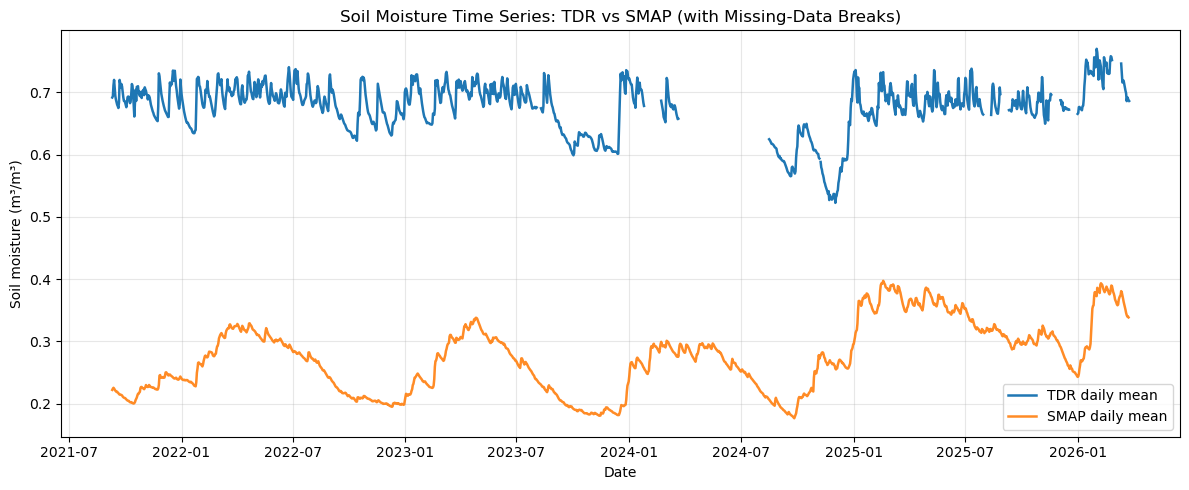

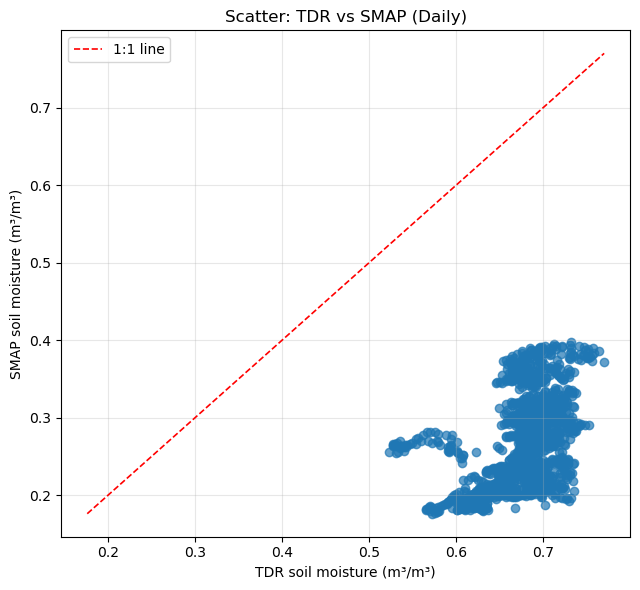

,Date,tdr_soil_moisture,smap_soil_moisture
0,2021-09-10,0.691829,0.222071
1,2021-09-11,0.693932,0.224030
2,2021-09-12,0.711466,0.225418
3,2021-09-13,0.720153,0.224245
4,2021-09-14,0.706234,0.222496


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
tdr_clean_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
smap_path = r"TDR_data\SMAP_RZ_clean.csv"

# Load TDR daily mean (already cleaned)
tdr = pd.read_csv(tdr_clean_path, parse_dates=["Date"])
tdr["Date"] = pd.to_datetime(tdr["Date"]).dt.normalize()
tdr = tdr[["Date", "VW_mean_all_sensors"]].dropna().sort_values("Date")

# Load SMAP and aggregate to daily mean to match TDR frequency
smap = pd.read_csv(smap_path, parse_dates=["datetime"])
smap["Date"] = pd.to_datetime(smap["datetime"]).dt.normalize()
smap_daily = (
    smap.groupby("Date", as_index=False)["soil_moisture"]
        .mean()
        .sort_values("Date")
)

# Inner join keeps only overlapping dates for fair comparison metrics
comparison_raw = pd.merge(tdr, smap_daily, on="Date", how="inner")
comparison_raw = comparison_raw.rename(columns={
    "VW_mean_all_sensors": "tdr_soil_moisture",
    "soil_moisture": "smap_soil_moisture"
})

# Quality control: keep physically plausible volumetric soil moisture [0, 1]
qc_mask = (
    comparison_raw["tdr_soil_moisture"].between(0, 1)
    & comparison_raw["smap_soil_moisture"].between(0, 1)
)
comparison = comparison_raw[qc_mask].copy()
removed = len(comparison_raw) - len(comparison)

# Metrics
r = comparison["tdr_soil_moisture"].corr(comparison["smap_soil_moisture"])
rmse = np.sqrt(np.mean((comparison["smap_soil_moisture"] - comparison["tdr_soil_moisture"]) ** 2))
bias = np.mean(comparison["smap_soil_moisture"] - comparison["tdr_soil_moisture"])

print(f"Overlapping days before QC: {len(comparison_raw)}")
print(f"Rows removed by QC: {removed}")
print(f"Overlapping days used: {len(comparison)}")
print(f"Correlation (R): {r:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Bias (SMAP - TDR): {bias:.4f}")

# Save merged comparison table for reporting
comparison_out = r"resultados\comparison_smap_vs_tdr_daily.csv"
comparison.to_csv(comparison_out, index=False)
print(f"Saved comparison table to: {comparison_out}")

# Build continuous daily timeline to create visible breaks for missing data
plot_start = min(tdr["Date"].min(), smap_daily["Date"].min())
plot_end = max(tdr["Date"].max(), smap_daily["Date"].max())
full_timeline = pd.date_range(plot_start, plot_end, freq="D")

# For plotting, also convert out-of-range values to NaN so they appear as breaks
tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src["VW_mean_all_sensors"].between(0, 1), "VW_mean_all_sensors"] = np.nan
smap_plot_src = smap_daily.copy()
smap_plot_src.loc[~smap_plot_src["soil_moisture"].between(0, 1), "soil_moisture"] = np.nan

tdr_plot = tdr_plot_src.set_index("Date").reindex(full_timeline)["VW_mean_all_sensors"]
smap_plot = smap_plot_src.set_index("Date").reindex(full_timeline)["soil_moisture"]

print(f"TDR missing/invalid days shown as breaks: {tdr_plot.isna().sum()}")
print(f"SMAP missing/invalid days shown as breaks: {smap_plot.isna().sum()}")

# Time series plot with breaks on missing or invalid data
plt.figure(figsize=(12, 5))
plt.plot(full_timeline, tdr_plot, label="TDR daily mean", linewidth=1.8)
plt.plot(full_timeline, smap_plot, label="SMAP daily mean", linewidth=1.8, alpha=0.9)
plt.title("Soil Moisture Time Series: TDR vs SMAP (with Missing-Data Breaks)")
plt.xlabel("Date")
plt.ylabel("Soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot with 1:1 line (QC-filtered overlap only)
plt.figure(figsize=(6.5, 6))
plt.scatter(comparison["tdr_soil_moisture"], comparison["smap_soil_moisture"], alpha=0.7)
min_val = min(comparison["tdr_soil_moisture"].min(), comparison["smap_soil_moisture"].min())
max_val = max(comparison["tdr_soil_moisture"].max(), comparison["smap_soil_moisture"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.2, label="1:1 line")
plt.title("Scatter: TDR vs SMAP (Daily)")
plt.xlabel("TDR soil moisture (m³/m³)")
plt.ylabel("SMAP soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

comparison.head()

Overlap-only SMAP vs TDR
Days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved overlap-only table to: resultados\comparison_smap_vs_tdr_overlap_only.csv
Missing TDR days marked in red: 247


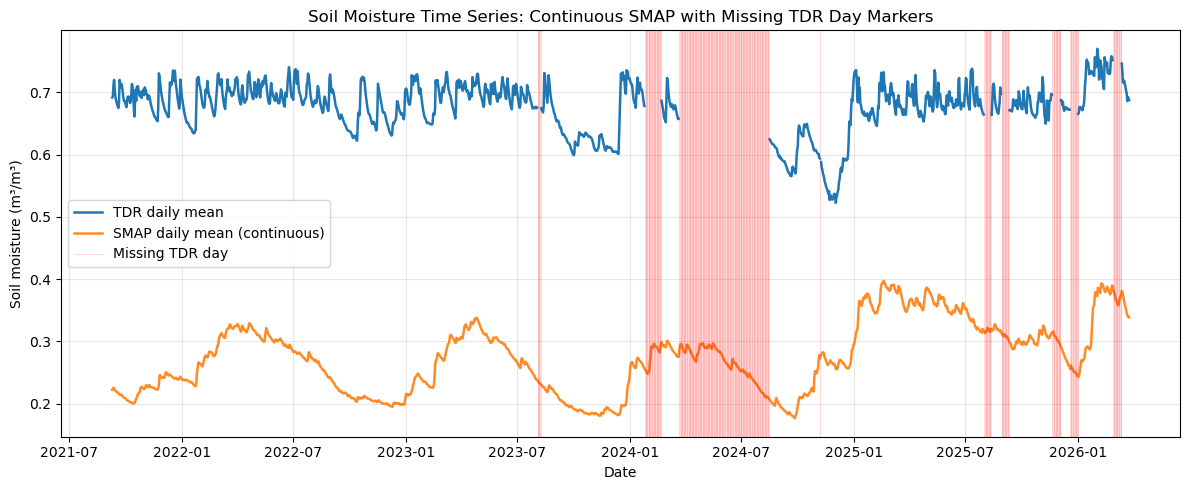

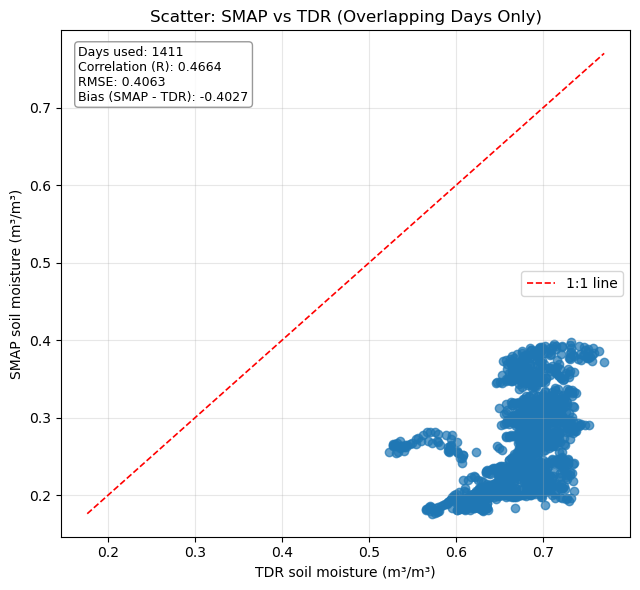

,Date,tdr_soil_moisture,smap_soil_moisture
0,2021-09-10,0.691829,0.222071
1,2021-09-11,0.693932,0.224030
2,2021-09-12,0.711466,0.225418
3,2021-09-13,0.720153,0.224245
4,2021-09-14,0.706234,0.222496


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Overlap-focused metrics, but plotting uses full SMAP timeline
# so SMAP appears continuous while missing TDR days are highlighted.
tdr_clean_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
smap_path = r"TDR_data\SMAP_RZ_clean.csv"

# Load TDR clean daily mean
tdr = pd.read_csv(tdr_clean_path, parse_dates=["Date"])
tdr["Date"] = pd.to_datetime(tdr["Date"]).dt.normalize()
tdr = tdr[["Date", "VW_mean_all_sensors"]].rename(columns={"VW_mean_all_sensors": "tdr_soil_moisture"})

# Load SMAP daily mean
smap = pd.read_csv(smap_path, parse_dates=["datetime"])
smap["Date"] = pd.to_datetime(smap["datetime"]).dt.normalize()
smap_daily = smap.groupby("Date", as_index=False)["soil_moisture"].mean()
smap_daily = smap_daily.rename(columns={"soil_moisture": "smap_soil_moisture"}).sort_values("Date")

# Overlap-only table for metrics
overlap = pd.merge(tdr, smap_daily, on="Date", how="inner").sort_values("Date")
overlap = overlap[
    overlap["tdr_soil_moisture"].between(0, 1)
    & overlap["smap_soil_moisture"].between(0, 1)
]

# Metrics on overlapping days
r_overlap = overlap["tdr_soil_moisture"].corr(overlap["smap_soil_moisture"])
rmse_overlap = np.sqrt(np.mean((overlap["smap_soil_moisture"] - overlap["tdr_soil_moisture"]) ** 2))
bias_overlap = np.mean(overlap["smap_soil_moisture"] - overlap["tdr_soil_moisture"])

print("Overlap-only SMAP vs TDR")
print(f"Days used: {len(overlap)}")
print(f"Correlation (R): {r_overlap:.4f}")
print(f"RMSE: {rmse_overlap:.4f}")
print(f"Bias (SMAP - TDR): {bias_overlap:.4f}")

overlap_out = r"resultados\comparison_smap_vs_tdr_overlap_only.csv"
overlap.to_csv(overlap_out, index=False)
print(f"Saved overlap-only table to: {overlap_out}")

# Build SMAP timeline for continuous SMAP line
plot_start = smap_daily["Date"].min()
plot_end = smap_daily["Date"].max()
plot_timeline = pd.date_range(plot_start, plot_end, freq="D")

# SMAP continuous daily line (no forced breaks apart from true SMAP-missing days)
smap_plot = smap_daily.set_index("Date").reindex(plot_timeline)["smap_soil_moisture"]

# TDR plotted on same timeline; missing TDR days remain NaN
tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src["tdr_soil_moisture"].between(0, 1), "tdr_soil_moisture"] = np.nan
tdr_plot = tdr_plot_src.set_index("Date").reindex(plot_timeline)["tdr_soil_moisture"]

# Missing TDR days where SMAP has data (these will be marked with red vertical lines)
missing_tdr_days = tdr_plot.index[tdr_plot.isna() & smap_plot.notna()]
print(f"Missing TDR days marked in red: {len(missing_tdr_days)}")

# Time series: continuous SMAP + TDR + softer red markers for missing TDR days
plt.figure(figsize=(12, 5))
plt.plot(plot_timeline, tdr_plot, label="TDR daily mean", linewidth=1.8)
plt.plot(plot_timeline, smap_plot, label="SMAP daily mean (continuous)", linewidth=1.8, alpha=0.9)

for i, d in enumerate(missing_tdr_days):
    plt.axvline(
        d,
        color="red",
        linewidth=0.6,
        alpha=0.18,
        label="Missing TDR day" if i == 0 else None
    )

plt.title("Soil Moisture Time Series: Continuous SMAP with Missing TDR Day Markers")
plt.xlabel("Date")
plt.ylabel("Soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot with 1:1 line (overlap-only)
plt.figure(figsize=(6.5, 6))
plt.scatter(overlap["tdr_soil_moisture"], overlap["smap_soil_moisture"], alpha=0.7)
min_val = min(overlap["tdr_soil_moisture"].min(), overlap["smap_soil_moisture"].min())
max_val = max(overlap["tdr_soil_moisture"].max(), overlap["smap_soil_moisture"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.2, label="1:1 line")
stats_text = (
    f"Days used: {len(overlap)}\n"
    f"Correlation (R): {r_overlap:.4f}\n"
    f"RMSE: {rmse_overlap:.4f}\n"
    f"Bias (SMAP - TDR): {bias_overlap:.4f}"
)
ax = plt.gca()
ax.text(
    0.03,
    0.97,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "gray"},
)
plt.title("Scatter: SMAP vs TDR (Overlapping Days Only)")
plt.xlabel("TDR soil moisture (m³/m³)")
plt.ylabel("SMAP soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

overlap.head()

Missing TDR days marked in red (z-score plot): 247


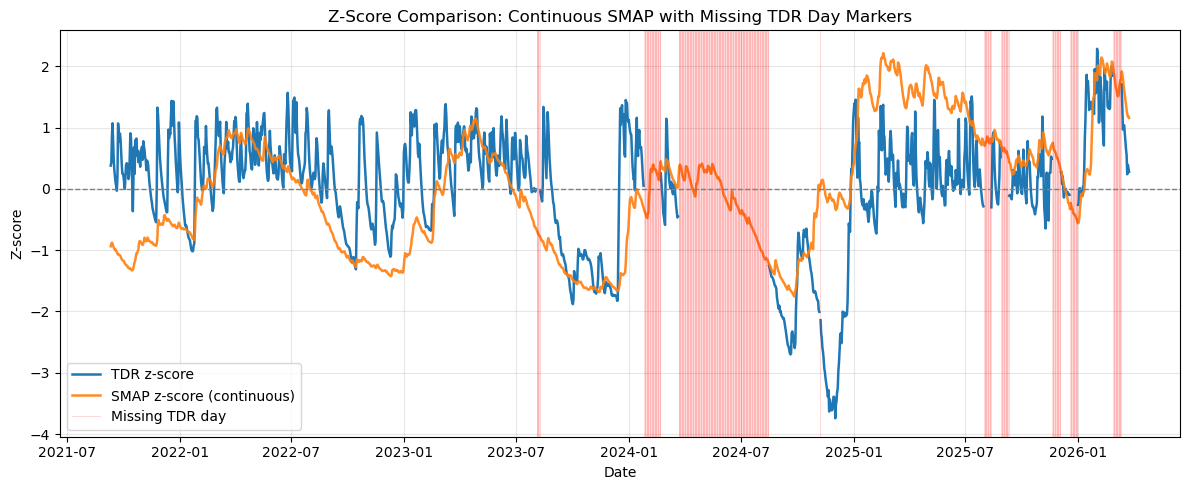

Missing days shown as breaks in overlap-only z-score plot: 247


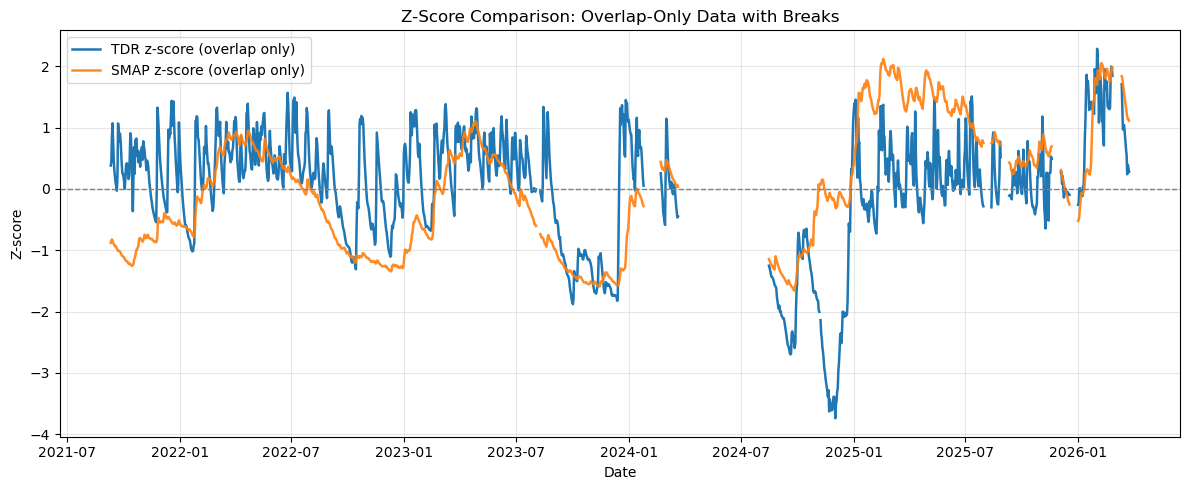

,Date,tdr_z,smap_z
0,2021-09-10,0.380729,-0.880222
1,2021-09-11,0.431930,-0.846670
2,2021-09-12,0.858747,-0.822900
3,2021-09-13,1.070219,-0.842994
4,2021-09-14,0.731391,-0.872950


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Plot 1: overlap-only z-score with continuous SMAP + TDR red gap markers ----------
if "overlap" not in globals():
    overlap = pd.read_csv(r"resultados\comparison_smap_vs_tdr_overlap_only.csv", parse_dates=["Date"])
else:
    overlap = overlap.copy()

overlap = overlap.sort_values("Date")

tdr_overlap = overlap["tdr_soil_moisture"]
smap_overlap = overlap["smap_soil_moisture"]

tdr_z = (tdr_overlap - tdr_overlap.mean()) / tdr_overlap.std()
smap_z = (smap_overlap - smap_overlap.mean()) / smap_overlap.std()

z_df = pd.DataFrame({
    "Date": overlap["Date"],
    "tdr_z": tdr_z,
    "smap_z": smap_z
}).set_index("Date")

# Use full SMAP z-score range for continuous plotting
smap_full = pd.read_csv(r"TDR_data\SMAP_RZ_clean.csv", parse_dates=["datetime"])
smap_full["Date"] = pd.to_datetime(smap_full["datetime"]).dt.normalize()
smap_full_daily = smap_full.groupby("Date", as_index=False)["soil_moisture"].mean().sort_values("Date")
smap_full_daily["smap_z_full"] = (
    smap_full_daily["soil_moisture"] - smap_full_daily["soil_moisture"].mean()
) / smap_full_daily["soil_moisture"].std()

# TDR from clean series
tdr_clean_full = pd.read_csv(
    r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv",
    parse_dates=["Date"]
)
tdr_clean_full["Date"] = pd.to_datetime(tdr_clean_full["Date"]).dt.normalize()
tdr_clean_full = tdr_clean_full[["Date", "VW_mean_all_sensors"]].drop_duplicates(subset="Date").sort_values("Date")

missing_days = pd.read_csv(
    r"resultados\missing_dates_daily_mean_all_sensors.csv",
    parse_dates=["date"]
)
missing_days["date"] = pd.to_datetime(missing_days["date"]).dt.normalize()
missing_set = set(missing_days["date"])

tdr_vals = tdr_clean_full["VW_mean_all_sensors"].where(
    tdr_clean_full["VW_mean_all_sensors"].between(0, 1)
)
tdr_clean_full["tdr_z_full"] = (tdr_vals - tdr_vals.mean()) / tdr_vals.std()

# Build timeline on full SMAP span
z_timeline = pd.date_range(smap_full_daily["Date"].min(), smap_full_daily["Date"].max(), freq="D")

# Reindex for plotting: SMAP continuous, TDR with NaN gaps
smap_z_plot = smap_full_daily.set_index("Date").reindex(z_timeline)["smap_z_full"]
tdr_z_plot = tdr_clean_full.set_index("Date").reindex(z_timeline)["tdr_z_full"]

# Enforce known missing TDR dates as NaN
tdr_z_plot.loc[tdr_z_plot.index.isin(missing_set)] = pd.NA

# Find missing TDR days where SMAP has data for red markers
missing_tdr_days_z = tdr_z_plot.index[tdr_z_plot.isna() & smap_z_plot.notna()]
print(f"Missing TDR days marked in red (z-score plot): {len(missing_tdr_days_z)}")

plt.figure(figsize=(12, 5))
plt.plot(z_timeline, tdr_z_plot, label="TDR z-score", linewidth=1.8)
plt.plot(z_timeline, smap_z_plot, label="SMAP z-score (continuous)", linewidth=1.8, alpha=0.9)

for i, d in enumerate(missing_tdr_days_z):
    plt.axvline(
        d,
        color="red",
        linewidth=0.6,
        alpha=0.18,
        label="Missing TDR day" if i == 0 else None
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Z-Score Comparison: Continuous SMAP with Missing TDR Day Markers")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Plot 2: alternative view (overlap-only z-score with breaks on both) ----------
z_timeline_overlap = pd.date_range(z_df.index.min(), z_df.index.max(), freq="D")
z_plot_overlap = z_df.reindex(z_timeline_overlap)

print(f"Missing days shown as breaks in overlap-only z-score plot: {z_plot_overlap['tdr_z'].isna().sum()}")

plt.figure(figsize=(12, 5))
plt.plot(z_timeline_overlap, z_plot_overlap["tdr_z"], label="TDR z-score (overlap only)", linewidth=1.8)
plt.plot(z_timeline_overlap, z_plot_overlap["smap_z"], label="SMAP z-score (overlap only)", linewidth=1.8, alpha=0.9)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Z-Score Comparison: Overlap-Only Data with Breaks")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

z_plot_overlap.reset_index().rename(columns={"index": "Date"}).head()

Detailed SMAP vs TDR dynamics
Total overlapping days analysed: 1411
Overall mean bias (SMAP - TDR): -0.4027
Overall mean absolute error: 0.4027
Underestimation share: 100.0%
Overestimation share: 0.0%
Worst calendar month by mean bias: Oct (-0.4340)
Worst calendar month by MAE: Oct (0.4340)
Worst year-month by MAE: 2021-10 (0.4837)
Best short lag for correlation: -2 days (r = 0.4719)
Saved summaries:
 - resultados\smap_tdr_monthly_difference_summary.csv
 - resultados\smap_tdr_year_month_difference_summary.csv
 - resultados\smap_tdr_regime_difference_summary.csv
 - resultados\smap_strongest_underestimation_days.csv
 - resultados\smap_weakest_underestimation_days.csv

Calendar-month summary ordered by mean bias:


,month_name,days,mean_tdr,mean_smap,mean_bias,mae,rmse,corr,amplitude_ratio_smap_to_tdr,direction
9,Oct,155,0.659090,0.225125,-0.433965,0.433965,0.436033,0.352164,1.185973,SMAP underestimates
8,Sep,131,0.646979,0.220243,-0.426736,0.426736,0.428082,0.655036,0.801525,SMAP underestimates
11,Dec,139,0.656586,0.230896,-0.425690,0.425690,0.430303,-0.052224,0.647851,SMAP underestimates
7,Aug,88,0.674166,0.250197,-0.423969,0.423969,0.425639,0.463294,1.200460,SMAP underestimates
0,Jan,149,0.693295,0.277976,-0.415319,0.415319,0.419092,0.128029,1.681070,SMAP underestimates
6,Jul,93,0.696346,0.288999,-0.407347,0.407347,0.408776,0.123572,1.647580,SMAP underestimates
10,Nov,138,0.639115,0.233925,-0.405190,0.405190,0.411066,-0.040641,0.814713,SMAP underestimates
5,Jun,90,0.694827,0.311451,-0.383376,0.383376,0.385171,-0.378710,1.972554,SMAP underestimates
1,Feb,118,0.694545,0.316973,-0.377573,0.377573,0.380234,0.663902,1.807089,SMAP underestimates
2,Mar,127,0.695320,0.323977,-0.371343,0.371343,0.373655,-0.012326,1.817001,SMAP underestimates



Moisture-regime summary:


,tdr_regime,days,mean_tdr,mean_smap,mean_bias,mae,corr,direction
0,Dry,471,0.630603,0.235133,-0.395469,0.395469,0.266303,SMAP underestimates
1,Transition,470,0.683570,0.290624,-0.392946,0.392946,0.033917,SMAP underestimates
2,Wet,470,0.714489,0.294716,-0.419773,0.419773,0.219203,SMAP underestimates



Strongest SMAP underestimation days:


,Date,tdr_soil_moisture,smap_soil_moisture,diff_smap_minus_tdr,abs_diff
823,2023-12-18,0.730213,0.192895,-0.537318,0.537318
826,2023-12-21,0.732320,0.196672,-0.535648,0.535648
825,2023-12-20,0.727418,0.196643,-0.530774,0.530774
828,2023-12-23,0.726287,0.195867,-0.530421,0.530421
832,2023-12-27,0.735782,0.205824,-0.529958,0.529958
827,2023-12-22,0.721776,0.196427,-0.525348,0.525348
824,2023-12-19,0.719212,0.197734,-0.521478,0.521478
408,2022-10-23,0.725109,0.208402,-0.516708,0.516708
829,2023-12-24,0.713298,0.197090,-0.516208,0.516208
822,2023-12-17,0.702323,0.187447,-0.514876,0.514876



Days with the weakest underestimation (no true overestimation found):


,Date,tdr_soil_moisture,smap_soil_moisture,diff_smap_minus_tdr,abs_diff
988,2024-11-22,0.527048,0.266579,-0.260469,0.260469
992,2024-11-26,0.527787,0.265231,-0.262556,0.262556
991,2024-11-25,0.530224,0.266031,-0.264193,0.264193
993,2024-11-27,0.528179,0.263293,-0.264886,0.264886
990,2024-11-24,0.532647,0.267112,-0.265534,0.265534
989,2024-11-23,0.535298,0.269744,-0.265554,0.265554
998,2024-12-02,0.522530,0.256363,-0.266168,0.266168
994,2024-11-28,0.530653,0.264091,-0.266562,0.266562
995,2024-11-29,0.536909,0.264321,-0.272588,0.272588
986,2024-11-20,0.536841,0.263272,-0.273568,0.273568


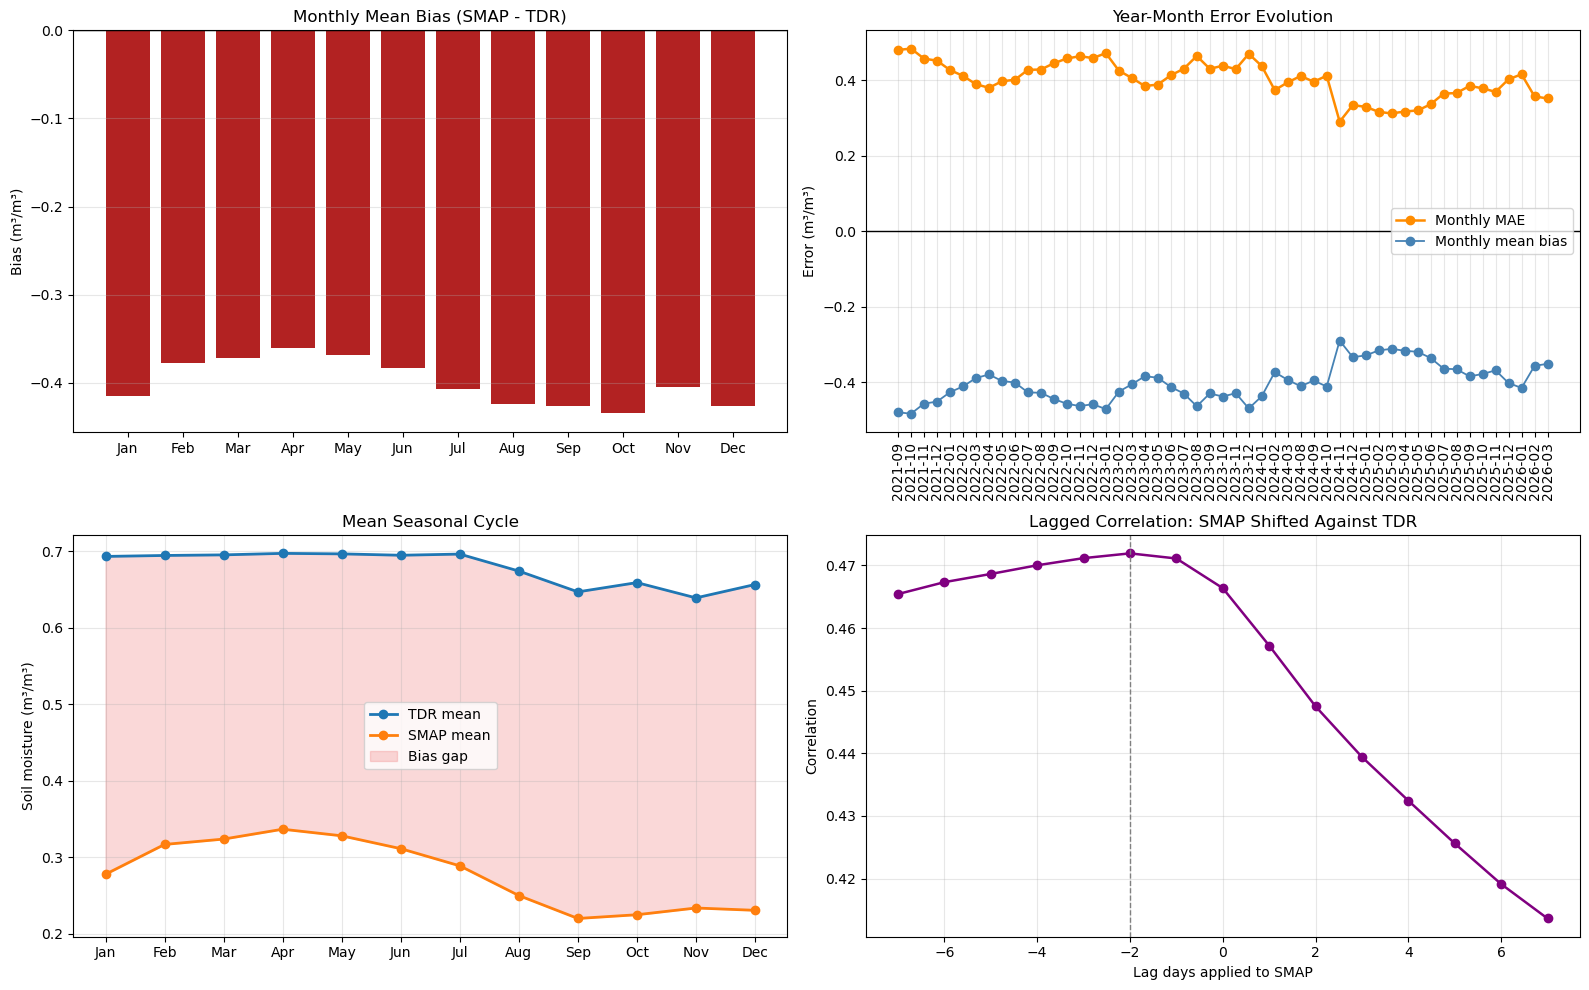

,month,month_name,days,mean_tdr,mean_smap,mean_bias,median_bias,mae,rmse,corr,tdr_std,smap_std,amplitude_ratio_smap_to_tdr,direction
9,10,Oct,155,0.659090,0.225125,-0.433965,-0.430984,0.433965,0.436033,0.352164,0.033950,0.040263,1.185973,SMAP underestimates
8,9,Sep,131,0.646979,0.220243,-0.426736,-0.428486,0.426736,0.428082,0.655036,0.044236,0.035456,0.801525,SMAP underestimates
11,12,Dec,139,0.656586,0.230896,-0.425690,-0.435194,0.425690,0.430303,-0.052224,0.051711,0.033501,0.647851,SMAP underestimates
7,8,Aug,88,0.674166,0.250197,-0.423969,-0.418199,0.423969,0.425639,0.463294,0.032868,0.039457,1.200460,SMAP underestimates
0,1,Jan,149,0.693295,0.277976,-0.415319,-0.428654,0.415319,0.419092,0.128029,0.030550,0.051356,1.681070,SMAP underestimates
6,7,Jul,93,0.696346,0.288999,-0.407347,-0.418780,0.407347,0.408776,0.123572,0.018881,0.031107,1.647580,SMAP underestimates
10,11,Nov,138,0.639115,0.233925,-0.405190,-0.432301,0.405190,0.411066,-0.040641,0.052846,0.043054,0.814713,SMAP underestimates
5,6,Jun,90,0.694827,0.311451,-0.383376,-0.393210,0.383376,0.385171,-0.378710,0.014783,0.029161,1.972554,SMAP underestimates
1,2,Feb,118,0.694545,0.316973,-0.377573,-0.383775,0.377573,0.380234,0.663902,0.033016,0.059663,1.807089,SMAP underestimates
2,3,Mar,127,0.695320,0.323977,-0.371343,-0.379875,0.371343,0.373655,-0.012326,0.019987,0.036316,1.817001,SMAP underestimates


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Detailed dynamics analysis based on the validated overlap table
if "overlap" in globals() and {"Date", "tdr_soil_moisture", "smap_soil_moisture"}.issubset(overlap.columns):
    diff_df = overlap.copy()
else:
    diff_df = pd.read_csv(
        r"resultados\comparison_smap_vs_tdr_overlap_only.csv",
        parse_dates=["Date"]
    )

diff_df["Date"] = pd.to_datetime(diff_df["Date"]).dt.normalize()
diff_df = diff_df.sort_values("Date").reset_index(drop=True)
diff_df["diff_smap_minus_tdr"] = diff_df["smap_soil_moisture"] - diff_df["tdr_soil_moisture"]
diff_df["abs_diff"] = diff_df["diff_smap_minus_tdr"].abs()
diff_df["month"] = diff_df["Date"].dt.month
diff_df["month_name"] = diff_df["Date"].dt.month_name().str.slice(0, 3)
diff_df["year_month"] = diff_df["Date"].dt.to_period("M").astype(str)

month_summary = (
    diff_df.groupby(["month", "month_name"], as_index=False)
    .agg(
        days=("Date", "size"),
        mean_tdr=("tdr_soil_moisture", "mean"),
        mean_smap=("smap_soil_moisture", "mean"),
        mean_bias=("diff_smap_minus_tdr", "mean"),
        median_bias=("diff_smap_minus_tdr", "median"),
        mae=("abs_diff", "mean"),
        rmse=("diff_smap_minus_tdr", lambda s: np.sqrt(np.mean(np.square(s)))),
        corr=("smap_soil_moisture", lambda s: s.corr(diff_df.loc[s.index, "tdr_soil_moisture"])),
        tdr_std=("tdr_soil_moisture", "std"),
        smap_std=("smap_soil_moisture", "std")
    )
    .sort_values("month")
    .reset_index(drop=True)
 )
month_summary["amplitude_ratio_smap_to_tdr"] = month_summary["smap_std"] / month_summary["tdr_std"]
month_summary["direction"] = np.where(month_summary["mean_bias"] >= 0, "SMAP overestimates", "SMAP underestimates")

year_month_summary = (
    diff_df.groupby("year_month", as_index=False)
    .agg(
        days=("Date", "size"),
        mean_tdr=("tdr_soil_moisture", "mean"),
        mean_smap=("smap_soil_moisture", "mean"),
        mean_bias=("diff_smap_minus_tdr", "mean"),
        mae=("abs_diff", "mean"),
        rmse=("diff_smap_minus_tdr", lambda s: np.sqrt(np.mean(np.square(s))))
    )
    .sort_values("year_month")
 )
year_month_summary["direction"] = np.where(year_month_summary["mean_bias"] >= 0, "SMAP overestimates", "SMAP underestimates")

regime_labels = ["Dry", "Transition", "Wet"]
diff_df["tdr_regime"] = pd.qcut(diff_df["tdr_soil_moisture"], q=3, labels=regime_labels)
regime_summary = (
    diff_df.groupby("tdr_regime", observed=False, as_index=False)
    .agg(
        days=("Date", "size"),
        mean_tdr=("tdr_soil_moisture", "mean"),
        mean_smap=("smap_soil_moisture", "mean"),
        mean_bias=("diff_smap_minus_tdr", "mean"),
        mae=("abs_diff", "mean"),
        corr=("smap_soil_moisture", lambda s: s.corr(diff_df.loc[s.index, "tdr_soil_moisture"]))
    )
 )
regime_summary["direction"] = np.where(regime_summary["mean_bias"] >= 0, "SMAP overestimates", "SMAP underestimates")

lag_rows = []
for lag in range(-7, 8):
    lagged_smap = diff_df["smap_soil_moisture"].shift(lag)
    valid = lagged_smap.notna() & diff_df["tdr_soil_moisture"].notna()
    if valid.sum() < 10:
        continue
    lag_rows.append({
        "lag_days": lag,
        "correlation": diff_df.loc[valid, "tdr_soil_moisture"].corr(lagged_smap.loc[valid])
    })

lag_summary = pd.DataFrame(lag_rows)
best_lag = lag_summary.loc[lag_summary["correlation"].idxmax()]

under_days = diff_df[diff_df["diff_smap_minus_tdr"] < 0].copy()
over_days = diff_df[diff_df["diff_smap_minus_tdr"] > 0].copy()
top_under = under_days.nsmallest(10, "diff_smap_minus_tdr")[["Date", "tdr_soil_moisture", "smap_soil_moisture", "diff_smap_minus_tdr", "abs_diff"]]
if over_days.empty:
    top_over = diff_df.nlargest(10, "diff_smap_minus_tdr")[["Date", "tdr_soil_moisture", "smap_soil_moisture", "diff_smap_minus_tdr", "abs_diff"]]
    top_over_title = "Days with the weakest underestimation (no true overestimation found)"
    top_over_out = r"resultados\smap_weakest_underestimation_days.csv"
else:
    top_over = over_days.nlargest(10, "diff_smap_minus_tdr")[["Date", "tdr_soil_moisture", "smap_soil_moisture", "diff_smap_minus_tdr", "abs_diff"]]
    top_over_title = "Strongest SMAP overestimation days"
    top_over_out = r"resultados\smap_strongest_overestimation_days.csv"

month_summary_out = r"resultados\smap_tdr_monthly_difference_summary.csv"
year_month_out = r"resultados\smap_tdr_year_month_difference_summary.csv"
regime_out = r"resultados\smap_tdr_regime_difference_summary.csv"
top_under_out = r"resultados\smap_strongest_underestimation_days.csv"

month_summary.to_csv(month_summary_out, index=False)
year_month_summary.to_csv(year_month_out, index=False)
regime_summary.to_csv(regime_out, index=False)
top_under.to_csv(top_under_out, index=False)
top_over.to_csv(top_over_out, index=False)

worst_month_bias = month_summary.loc[month_summary["mean_bias"].idxmin()]
worst_month_mae = month_summary.loc[month_summary["mae"].idxmax()]
worst_year_month = year_month_summary.loc[year_month_summary["mae"].idxmax()]
under_share = (diff_df["diff_smap_minus_tdr"] < 0).mean() * 100
over_share = (diff_df["diff_smap_minus_tdr"] > 0).mean() * 100

print("Detailed SMAP vs TDR dynamics")
print(f"Total overlapping days analysed: {len(diff_df)}")
print(f"Overall mean bias (SMAP - TDR): {diff_df['diff_smap_minus_tdr'].mean():.4f}")
print(f"Overall mean absolute error: {diff_df['abs_diff'].mean():.4f}")
print(f"Underestimation share: {under_share:.1f}%")
print(f"Overestimation share: {over_share:.1f}%")
print(f"Worst calendar month by mean bias: {worst_month_bias['month_name']} ({worst_month_bias['mean_bias']:.4f})")
print(f"Worst calendar month by MAE: {worst_month_mae['month_name']} ({worst_month_mae['mae']:.4f})")
print(f"Worst year-month by MAE: {worst_year_month['year_month']} ({worst_year_month['mae']:.4f})")
print(f"Best short lag for correlation: {int(best_lag['lag_days'])} days (r = {best_lag['correlation']:.4f})")
print("Saved summaries:")
print(f" - {month_summary_out}")
print(f" - {year_month_out}")
print(f" - {regime_out}")
print(f" - {top_under_out}")
print(f" - {top_over_out}")

print("\nCalendar-month summary ordered by mean bias:")
display(month_summary[["month_name", "days", "mean_tdr", "mean_smap", "mean_bias", "mae", "rmse", "corr", "amplitude_ratio_smap_to_tdr", "direction"]].sort_values("mean_bias"))

print("\nMoisture-regime summary:")
display(regime_summary)

print("\nStrongest SMAP underestimation days:")
display(top_under.head(10))

print(f"\n{top_over_title}:")
display(top_over.head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(month_summary["month_name"], month_summary["mean_bias"], color=np.where(month_summary["mean_bias"] < 0, "firebrick", "seagreen"))
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Monthly Mean Bias (SMAP - TDR)")
axes[0, 0].set_ylabel("Bias (m³/m³)")
axes[0, 0].grid(axis="y", alpha=0.3)

axes[0, 1].plot(year_month_summary["year_month"], year_month_summary["mae"], marker="o", linewidth=1.8, color="darkorange", label="Monthly MAE")
axes[0, 1].plot(year_month_summary["year_month"], year_month_summary["mean_bias"], marker="o", linewidth=1.3, color="steelblue", label="Monthly mean bias")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Year-Month Error Evolution")
axes[0, 1].set_ylabel("Error (m³/m³)")
axes[0, 1].tick_params(axis="x", rotation=90)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(month_summary["month_name"], month_summary["mean_tdr"], marker="o", linewidth=2, label="TDR mean")
axes[1, 0].plot(month_summary["month_name"], month_summary["mean_smap"], marker="o", linewidth=2, label="SMAP mean")
axes[1, 0].fill_between(month_summary["month_name"], month_summary["mean_smap"], month_summary["mean_tdr"], color="lightcoral", alpha=0.3, label="Bias gap")
axes[1, 0].set_title("Mean Seasonal Cycle")
axes[1, 0].set_ylabel("Soil moisture (m³/m³)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lag_summary["lag_days"], lag_summary["correlation"], marker="o", linewidth=1.8, color="purple")
axes[1, 1].axvline(best_lag["lag_days"], color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_title("Lagged Correlation: SMAP Shifted Against TDR")
axes[1, 1].set_xlabel("Lag days applied to SMAP")
axes[1, 1].set_ylabel("Correlation")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

month_summary.sort_values("mean_bias")